- Create Data

In [ ]:
employees_data = [
    (1, "Ali", 3000),
    (2, "Sara", 7000),
    (3, "Omar", None),
    (4, "Mona", 10000)
]
employees = spark.createDataFrame(employees_data, ["id", "name", "salary"])

departments_data = [
    (1, "HR"),
    (2, "IT"),
    (2, "IT_DUPLICATE"),
    (3, "Finance")
]
departments = spark.createDataFrame(departments_data, ["id", "department"])

print("Employees Table")
employees.show()
print("Departments Table")
departments.show()

![Screenshot 2026-05-20 211433.png](<attachment:Screenshot 2026-05-20 211433.png>)
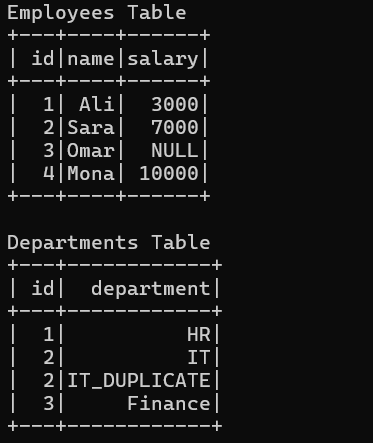

- Join the two dataframe

In [ ]:
joined_df = employees.join(departments, on="id", how="inner")
print("Joined DataFrame")
joined_df.show()

![Screenshot 2026-05-20 211652.png](<attachment:Screenshot 2026-05-20 211652.png>)
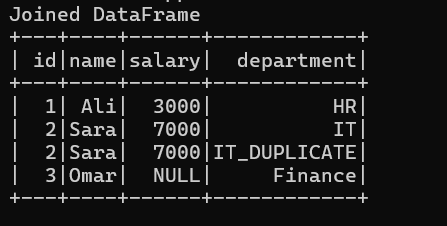

 Debug Task:
- Why does id=2 appear multiple times? Because the departments table contains two different records with id=2
- What kind of data issue caused this? Duplicate Data


- Fix Join Issue

In [ ]:
clean_departments = departments.dropDuplicates(["id"])
fixed_joined_df = employees.join(clean_departments, on="id", how="inner")
print("Fixed Joined DataFrame")
fixed_joined_df.show() 

![Screenshot 2026-05-20 212142.png](<attachment:Screenshot 2026-05-20 212142.png>)
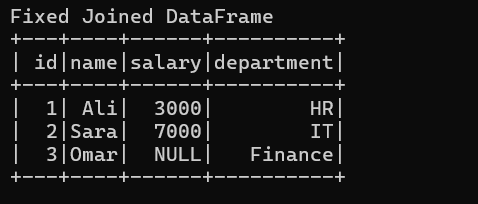

- categorize the employee salary with new column using Case When

In [ ]:
final_df = fixed_joined_df.withColumn(
    "salary_category",
    when(col("salary").isNull(), "Unknown")
    .when(col("salary") >= 5000, "High")
    .otherwise("Low")
)
final_df.show()

![Screenshot 2026-05-20 212209.png](<attachment:Screenshot 2026-05-20 212209.png>)
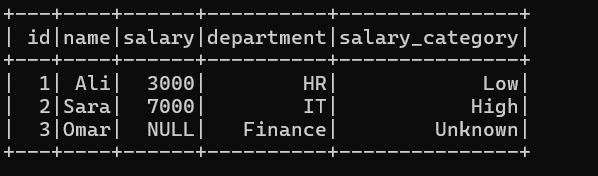